# Preprocessing Pipeline
*In this notebook we will cleanse our data.  
The process will include HTML tag removal, lowercasing, punctuation & stopword removal and lemmatization.*  

The notebook will demonstrate how the data looks before, and after each preprocessing step.  

***Prerequisite***: run the `download_nltk_data.py` from the project's root once prior to running this notebook.

**0. Setup**  

We load the dataset and pick sample reviews and follow them being cleansed.

In [19]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import textwrap

# Download NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

df = pd.read_csv('../data/IMDB Dataset.csv')
print(f"Dataset loaded: {df.shape[0]:,} reviews\n")

# Raw samples used for preprocessing logic
sample_pos = df[df['sentiment'] == 'positive']['review'].iloc[0]
sample_neg = df[df['sentiment'] == 'negative']['review'].iloc[0]

# Readable display helper function: take first `chars` and wrap to `width`
def display_snippet(text: str, chars: int = 500, width: int = 120) -> str:
    return textwrap.fill(text[:chars], width=width)

print("=== SAMPLE POSITIVE REVIEW (first 500 chars) ===")
print(display_snippet(sample_pos))
print("\n=== SAMPLE NEGATIVE REVIEW (first 500 chars) ===")
print(display_snippet(sample_neg))

Dataset loaded: 50,000 reviews

=== SAMPLE POSITIVE REVIEW (first 500 chars) ===
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this
is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching
scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid.
This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br
/><br />It is called OZ

=== SAMPLE NEGATIVE REVIEW (first 500 chars) ===
Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting
all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill
the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a drama!
As a drama t

**1. Remove HTML tags**  

IMDB reviews contain raw HTML tags like `<br />`. We strip all these tags before our analysis.  
The tags increase token count and add noise without any value.

In [21]:
def remove_html_tags(text: str) -> str:
    return re.sub(r'<.*?>', '', text)

print("=== BEFORE HTML removal (first 500 chars) ===")
print(display_snippet(sample_pos))
print("\n=== AFTER HTML removal (first 500 chars) ===")
print(display_snippet(remove_html_tags(sample_pos)))

=== BEFORE HTML removal (first 500 chars) ===
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this
is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching
scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid.
This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br
/><br />It is called OZ

=== AFTER HTML removal (first 500 chars) ===
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this
is exactly what happened with me.The first thing that struck me about Oz was its brutality and unflinching scenes of
violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show
pulls no punches with regards to drugs, sex or viol

**2. Lowercase**  

Normalises casing so that `"Good"`, `"GOOD"`, and `"good"` all map to the same token.  
This step ensure we have a consistent vocabulary, without it the vocabulary triples (for no reason).

In [22]:
def to_lowercase(text: str) -> str:
    return text.lower()

after_html = remove_html_tags(sample_pos)
print("=== BEFORE Lowercasing (first 500 chars) ===")
print(display_snippet(after_html))
print("\n=== AFTER Lowercasing (first 500 chars) ===")
print(display_snippet(to_lowercase(after_html)))

=== BEFORE Lowercasing (first 500 chars) ===
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this
is exactly what happened with me.The first thing that struck me about Oz was its brutality and unflinching scenes of
violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show
pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.It is called OZ
as that is the nickname

=== AFTER Lowercasing (first 500 chars) ===
one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this
is exactly what happened with me.the first thing that struck me about oz was its brutality and unflinching scenes of
violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show
pulls no punches with regards to drugs, sex or violen

**3. Remove special characters (punctuation & numbers)**  

Punctuation and digits contribute nothing to a bag-of-words model.  
Keeping them would bloat the vocabulary with tokens like `"!!!"` or `"2024"` that appear rarely and carry no transferable meaning.  
After this step we are keeping only letters and spaces.


In [23]:
def remove_special_characters(text: str) -> str:
    return re.sub(r'[^a-zA-Z\s]', '', text)

after_lower = to_lowercase(remove_html_tags(sample_pos))
print("=== BEFORE — Special character removal (first 500 chars) ===")
print(display_snippet(after_lower))
print("\n=== AFTER — Special character removal (first 500 chars) ===")
print(display_snippet(remove_special_characters(after_lower)))

=== BEFORE — Special character removal (first 500 chars) ===
one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this
is exactly what happened with me.the first thing that struck me about oz was its brutality and unflinching scenes of
violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show
pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.it is called oz
as that is the nickname

=== AFTER — Special character removal (first 500 chars) ===
one of the other reviewers has mentioned that after watching just  oz episode youll be hooked they are right as this is
exactly what happened with methe first thing that struck me about oz was its brutality and unflinching scenes of
violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls
no punches with regards 

**4. Remove stopwords**  

Common words like `"the"`, `"is"`, `"at"` carry no sentiment signal and would bloat the feature space.  
We keep negation words intentionally because `"not good"` means the opposite of `"good"`,  
so removing `"not"` would destroy the signal.

In [24]:
def remove_stopwords(text: str) -> str:
    stop_words = set(stopwords.words('english'))
    # Keep negation words (reversing sentiment)
    negation_words = {'not', 'no', 'nor', 'neither', 'never', 'nobody',
                      'nothing', 'nowhere', 'hardly', 'barely', 'scarcely'}
    stop_words -= negation_words
    return ' '.join([w for w in text.split() if w not in stop_words])

after_special = remove_special_characters(to_lowercase(remove_html_tags(sample_pos)))
print("=== BEFORE Stopword removal (first 500 chars) ===")
print(display_snippet(after_special))
print("\n=== AFTER Stopword removal (first 500 chars) ===")
print(display_snippet(remove_stopwords(after_special)))

# Show negation is preserved
negation_example = "this movie is not good and it was never funny"
print(f"\n--- Negation preservation demo ---")
print(f"Input : {negation_example}")
print(f"Output: {remove_stopwords(negation_example)}")
print("→ 'not' and 'never' survive because they flip the sentiment")

=== BEFORE Stopword removal (first 500 chars) ===
one of the other reviewers has mentioned that after watching just  oz episode youll be hooked they are right as this is
exactly what happened with methe first thing that struck me about oz was its brutality and unflinching scenes of
violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls
no punches with regards to drugs sex or violence its is hardcore in the classic use of the wordit is called oz as that
is the nickname given to the

=== AFTER Stopword removal (first 500 chars) ===
one reviewers mentioned watching oz episode youll hooked right exactly happened methe first thing struck oz brutality
unflinching scenes violence set right word go trust not show faint hearted timid show pulls no punches regards drugs sex
violence hardcore classic use wordit called oz nickname given oswald maximum security state penitentary focuses mainly
emerald city experimental section prison 

**5. Lemmatization**  

Reduces words to their base (dictionary) form: `"running"` → `"run"`, `"movies"` → `"movie"`.  
This groups related forms under one token, shrinking the vocabulary without losing meaning.  
We prefer lemmatization over stemming because it always produces real words.

In [25]:
def lemmatize_text(text: str) -> str:
    lemmatizer = WordNetLemmatizer()
    return ' '.join([lemmatizer.lemmatize(w) for w in text.split()])

after_stop = remove_stopwords(remove_special_characters(to_lowercase(remove_html_tags(sample_pos))))
print("=== BEFORE Lemmatization (first 500 chars) ===")
print(display_snippet(after_stop))
print("\n=== AFTER Lemmatization (first 500 chars) ===")
print(display_snippet(lemmatize_text(after_stop)))

# Word-form examples
lemmatizer = WordNetLemmatizer()
examples = ['running', 'movies', 'flies', 'studies', 'was', 'better', 'acting']
print("\n--- Word form changes ---")
for w in examples:
    lemma = lemmatizer.lemmatize(w)
    changed = f"  {w:12} → {lemma}" + (" ✓" if w != lemma else "")
    print(changed)

=== BEFORE Lemmatization (first 500 chars) ===
one reviewers mentioned watching oz episode youll hooked right exactly happened methe first thing struck oz brutality
unflinching scenes violence set right word go trust not show faint hearted timid show pulls no punches regards drugs sex
violence hardcore classic use wordit called oz nickname given oswald maximum security state penitentary focuses mainly
emerald city experimental section prison cells glass fronts face inwards privacy not high agenda em city home manyaryans
muslims gangstas lati

=== AFTER Lemmatization (first 500 chars) ===
one reviewer mentioned watching oz episode youll hooked right exactly happened methe first thing struck oz brutality
unflinching scene violence set right word go trust not show faint hearted timid show pull no punch regard drug sex
violence hardcore classic use wordit called oz nickname given oswald maximum security state penitentary focus mainly
emerald city experimental section prison cell glass fron

**6. Full pipeline**  

All five steps combined in sequence:  
HTML → lowercase → punctuation → stopwords → lemmatize.  
We show both sample reviews through the complete pipeline, then measure how much the vocabulary shrinks at each stage.

In [26]:
def preprocess_text(text: str) -> str:
    """Full preprocessing pipeline:
    1. HTML removal      — IMDB-specific noise
    2. Lowercase          — 'Good' and 'good' are the same word
    3. Special chars      — punctuation doesn't help bag-of-words models
    4. Stopword removal   — 'the', 'is', 'at' carry no sentiment
    5. Lemmatization      — reduces vocabulary, groups related word forms
    """
    text = remove_html_tags(text)
    text = to_lowercase(text)
    text = remove_special_characters(text)
    text = remove_stopwords(text)
    text = lemmatize_text(text)
    return text

print("=== POSITIVE REVIEW ===")
print("RAW (first 500 chars):")
print(display_snippet(sample_pos))
print("\nCLEAN (first 500 chars):")
print(display_snippet(preprocess_text(sample_pos)))

print("\n" + "=" * 60)
print("\n=== NEGATIVE REVIEW ===")
print("RAW (first 500 chars):")
print(display_snippet(sample_neg))
print("\nCLEAN (first 500 chars):")
print(display_snippet(preprocess_text(sample_neg)))

=== POSITIVE REVIEW ===
RAW (first 500 chars):
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this
is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching
scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid.
This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br
/><br />It is called OZ

CLEAN (first 500 chars):
one reviewer mentioned watching oz episode youll hooked right exactly happened methe first thing struck oz brutality
unflinching scene violence set right word go trust not show faint hearted timid show pull no punch regard drug sex
violence hardcore classic use wordit called oz nickname given oswald maximum security state penitentary focus mainly
emerald city experimental section prison cell glass front face inwards privac

Raw                 : 102,522 unique words
HTML removed        : 103,651 unique words
Lowercased          :  94,889 unique words
No punctuation      :  54,355 unique words
No stopwords        :  54,221 unique words
Lemmatized          :  49,558 unique words


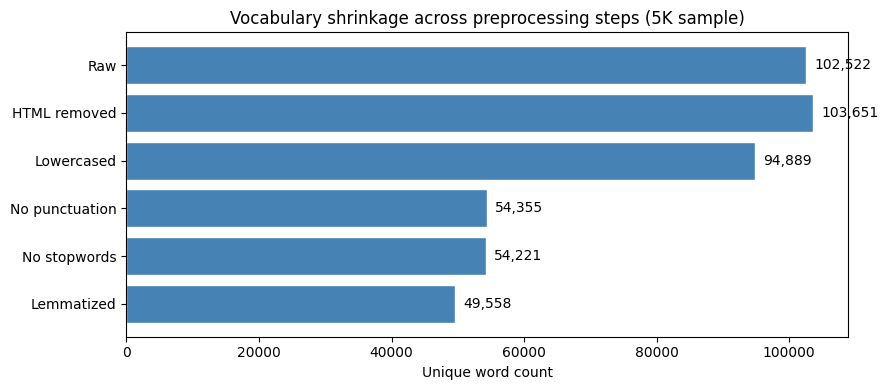

Saved → results/figures/vocabulary_shrinkage.png


In [27]:
# Vocabulary size at each preprocessing step (sample of 5,000 reviews for speed)
sample_reviews = df['review'].sample(5_000, random_state=42)

pipeline_steps = {
    'Raw':              lambda t: t,
    'HTML removed':     lambda t: remove_html_tags(t),
    'Lowercased':       lambda t: to_lowercase(remove_html_tags(t)),
    'No punctuation':   lambda t: remove_special_characters(to_lowercase(remove_html_tags(t))),
    'No stopwords':     lambda t: remove_stopwords(remove_special_characters(to_lowercase(remove_html_tags(t)))),
    'Lemmatized':       lambda t: preprocess_text(t),
}

vocab_sizes = {}
for label, fn in pipeline_steps.items():
    words = set()
    for text in sample_reviews:
        words.update(fn(text).split())
    vocab_sizes[label] = len(words)
    print(f"{label:20s}: {len(words):>7,} unique words")

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4))
labels = list(vocab_sizes.keys())
sizes  = list(vocab_sizes.values())
bars = ax.barh(labels, sizes, color='steelblue', edgecolor='white')
ax.bar_label(bars, labels=[f'{v:,}' for v in sizes], padding=6, fontsize=10)
ax.set_xlabel('Unique word count')
ax.set_title('Vocabulary shrinkage across preprocessing steps (5K sample)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../results/figures/vocabulary_shrinkage.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → results/figures/vocabulary_shrinkage.png")

**7. Apply to full dataset**  

We apply the pipeline to all 50,000 reviews and save the result to `data/imdb_preprocessed.csv`.  
This file will be the input for all subsequent notebooks, we never re-run preprocessing from scratch.

In [28]:
try:
    from tqdm.auto import tqdm
    tqdm.pandas(desc="Preprocessing")
    print("Applying preprocessing pipeline to all 50,000 reviews...")
    df['review_clean'] = df['review'].progress_apply(preprocess_text)
except ImportError:
    print("Applying preprocessing pipeline to all 50,000 reviews (no progress bar — install tqdm for one)...")
    df['review_clean'] = df['review'].apply(preprocess_text)

print(f"\nDone. Output shape: {df[['review_clean', 'sentiment']].shape}")

# Save
output_path = '../data/imdb_preprocessed.csv'
df[['review_clean', 'sentiment']].to_csv(output_path, index=False)
print(f"Saved → {output_path}")

df[['review_clean', 'sentiment']].head(3)

Applying preprocessing pipeline to all 50,000 reviews...


Preprocessing:   0%|          | 0/50000 [00:00<?, ?it/s]


Done. Output shape: (50000, 2)
Saved → ../data/imdb_preprocessed.csv


,review_clean,sentiment
0,one reviewer mentioned watching oz episode you...,positive
1,wonderful little production filming technique ...,positive
2,thought wonderful way spend time hot summer we...,positive
